In [1]:
import math, sys, time
import struct
from importlib import reload
from tqdm import tqdm
import time
import datetime

import pyvisa
import joblib
import numpy as np
import scipy

import helper_visa as vs
import helper_basic as hp
import helper_fft
import user_io.IO_rigol as uio

reload(uio)
import matplotlib.pylab as plt

# Device setting

In [2]:
## Address Examples
# address = None
address = "TCPIP::192.168.1.171::INSTR"
# address = "USB0::0xF4EC::0x1305::SSA3PCEX6R0308::INSTR"

device = vs.connect(address = address, timeout=10_000, idn=False) # set 10 second timeout

Connected to VISA [TCPIP::192.168.1.171::INSTR]:  RIGOL TECHNOLOGIES,DHO924,DHO9A250009316,00.01.05



# Acquisation setting

In [116]:
CHANNELS = [1,2,3]
LENGTH = 1_000_000 # 2**19
FFT_AVERAGE = 4

SAVE = True
SAVE_DIR = r'C:\Users\Tom\Downloads\2026-2-noise-hunting\test\\'
SAVE_FORMAT = "%Y%m%d_%H%M%S"


get_filename = lambda : SAVE_DIR + datetime.datetime.now().strftime(SAVE_FORMAT) + ".joblib"

In [117]:
reload(uio)

<module 'user_io.IO_rigol' from '/mnt/c/Users/Tom/OneDrive/Documents/JupyterNotebooks/CDMS/VisaScope/SpecExplorer/user_io/IO_rigol.py'>

In [115]:
rawdata, time_series = uio.read_waveform(device, read_channel=CHANNELS, acquire_length=LENGTH, calibrate=True, initialize=False)
# rawdata, time_series = read_waveform(device, read_channel=CHANNELS, acquire_length=LENGTH)

In [113]:
rawdata

{1: array([-0.000218  , -0.00019136, -0.00020136, ..., -0.00021579,
        -0.00018803, -0.00014808], dtype=float32),
 2: array([ 4.613391e-05, -2.880036e-05,  1.813356e-05, ..., -5.680071e-05,
        -5.200065e-05, -3.813381e-05], dtype=float32),
 3: array([0.00244216, 0.00239096, 0.0023867 , ..., 0.0023483 , 0.0024123 ,
        0.00240803], dtype=float32)}

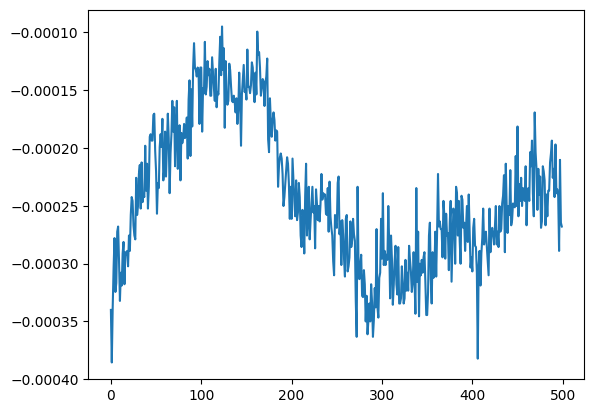

In [107]:
plt.plot(rawdata[1][:500])

In [118]:
LENGTH=1000_000
data = []
for i in tqdm(range(15)):
    rawdata, time_series = uio.read_waveform(device, read_channel=CHANNELS, acquire_length=LENGTH, calibrate=True)
    if len(rawdata[1])!=0:
        data.append(rawdata[1])
        time.sleep(0.1)
        fs =  1/(time_series[1]-time_series[0])

100%|███████████████████████████████████████████████████████████████████████████████████| 15/15 [00:50<00:00,  3.39s/it]


In [821]:
import scipy
R = 0.015
np.sqrt(4*scipy.constants.k*0.05/R)*1e12  

13.56784925230721

In [ ]:
f, pxx = scipy.signal.periodogram(data,fs = fs)
psd = np.sqrt(np.mean(pxx,axis=0))

In [ ]:
plt.loglog(f, psd)
f_bin, psd_bin = helper_fft.fft_logbin(psd**2, fs = fs, bins=4096)
plt.loglog(f_bin, np.sqrt(psd_bin))
plt.ylim(1e-9,)
plt.grid()